# Olist E-Commerce Sales & Customer Analytics

This notebook is the Python/Pandas portion of the portfolio project.

## Day 1 goals
- Load the datasets
- Understand their structure
- Check missing values and duplicates
- Create the first merged analysis table
- Calculate basic revenue metrics


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
DATA_DIR = Path('.')

## 1. Load the core datasets

In [2]:
orders = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
translation = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')
payments = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')

print('Orders:', orders.shape)
print('Customers:', customers.shape)
print('Items:', items.shape)
print('Products:', products.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Items: (112650, 7)
Products: (32951, 9)


## 2. Inspect the data

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


### Your task
Repeat `.head()`, `.info()` and `.isna().sum()` for the other core datasets. Write 2–3 observations in Markdown.

In [5]:
# Example: missing values in orders
orders.isna().sum().sort_values(ascending=False)

,0
order_delivered_customer_date,2965
order_delivered_carrier_date,1783
order_approved_at,160
order_id,0
order_purchase_timestamp,0
order_status,0
customer_id,0
order_estimated_delivery_date,0


## 3. Prepare date columns

In [7]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)

## 4. Merge orders, customers and order items

In [8]:
analysis = (
    orders
    .merge(customers, on='customer_id', how='left')
    .merge(items, on='order_id', how='left')
)

analysis.shape

(113425, 19)

## 5. Calculate basic revenue metrics

For this project, `price` is treated as item revenue before freight.

In [9]:
total_revenue = analysis['price'].sum()
total_orders = analysis['order_id'].nunique()
unique_customers = analysis['customer_unique_id'].nunique()

print(f'Total item revenue: R$ {total_revenue:,.2f}')
print(f'Total orders: {total_orders:,}')
print(f'Unique customers: {unique_customers:,}')

Total item revenue: R$ 13,591,643.70
Total orders: 99,441
Unique customers: 96,096


## 6. First business question: How does revenue change by month?

In [10]:
monthly_revenue = (
    analysis.groupby('order_month', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'revenue'})
)

monthly_revenue.head()

,order_month,revenue
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


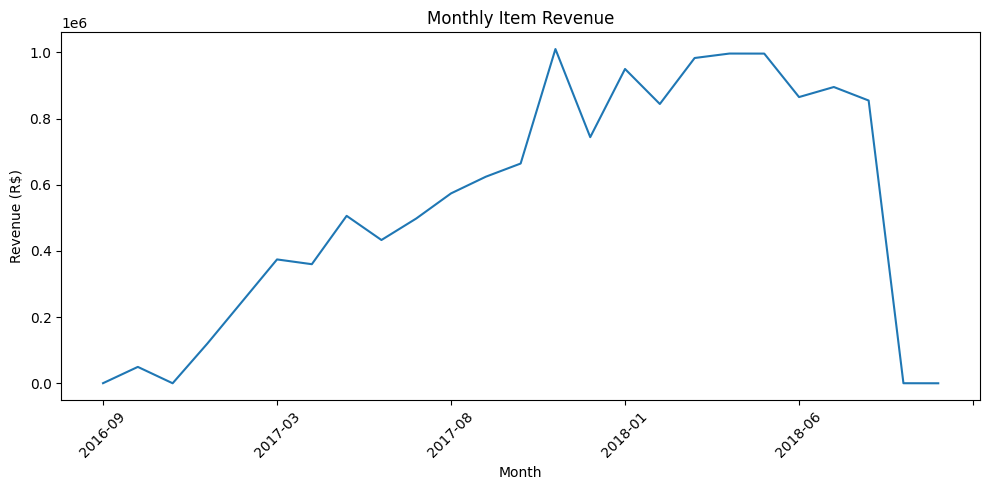

In [11]:
monthly_revenue.plot(x='order_month', y='revenue', kind='line', figsize=(10, 5), legend=False)
plt.title('Monthly Item Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
monthly_revenue.tail()

,order_month,revenue
20,2018-06,865124.31
21,2018-07,895507.22
22,2018-08,854686.33
23,2018-09,145.00
24,2018-10,0.00


In [13]:
monthly_revenue.sort_values('revenue', ascending=False).head()

,order_month,revenue
13,2017-11,1010271.37
18,2018-04,996647.75
19,2018-05,996517.68
17,2018-03,983213.44
15,2018-01,950030.36


Business Insight 1: Revenue increased strongly from early 2017 and remained at high levels throughout much of 2018. The highest-revenue month was November 2017, generating approximately R$1.01 million. September and October 2018 contain incomplete data, so the sharp decline at the end of the chart should not be interpreted as a genuine fall in business performance.

## 7. Your Day 1 observations

Write at least three observations here in your own words:

1. Observation 1: Revenue increased strongly during 2017 and stayed relatively high through most of 2018. November 2017 was the highest-revenue month at about R$1.01 million.

2. Observation 2: The dataset contains 99,441 orders but 96,096 unique customers, which shows that some customers placed more than one order.
3. Observation 3: Some delivery-related columns contain missing values, including 2,965 missing customer delivery dates. These should be investigated rather than automatically deleted because some orders may have been cancelled or not completed.


8. Business Question 2: Which product categories generate the most revenue?

In [14]:
analysis_products = (
    analysis
    .merge(products, on='product_id', how='left')
    .merge(translation, on='product_category_name', how='left')
)

analysis_products.shape

(113425, 28)

In [15]:
category_revenue = (
    analysis_products
    .groupby('product_category_name_english', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'revenue'})
    .sort_values('revenue', ascending=False)
)

category_revenue.head(10)

,product_category_name_english,revenue
43,health_beauty,1258681.34
70,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
65,sports_leisure,988048.97
15,computers_accessories,911954.32
39,furniture_decor,729762.49
20,cool_stuff,635290.85
49,housewares,632248.66
5,auto,592720.11
42,garden_tools,485256.46


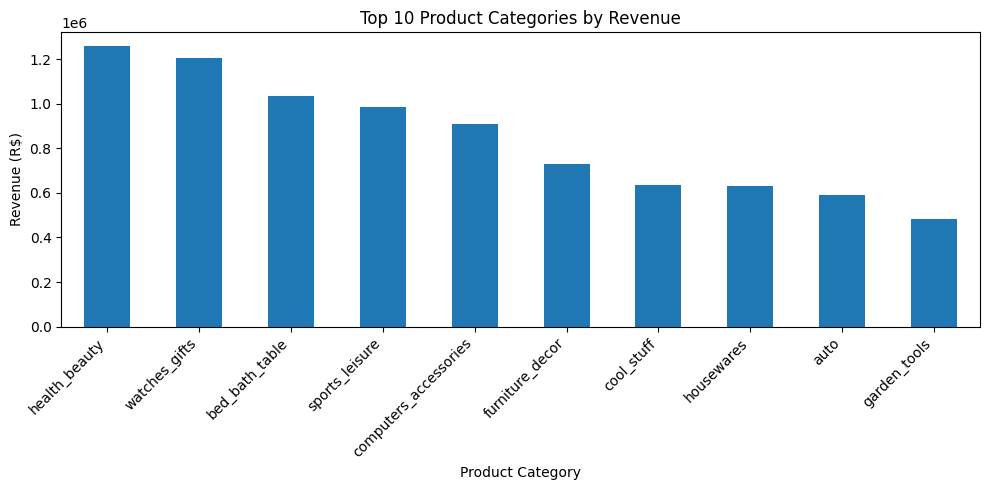

In [16]:
top_categories = category_revenue.head(10)

top_categories.plot(
    x='product_category_name_english',
    y='revenue',
    kind='bar',
    figsize=(10, 5),
    legend=False
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Business Insight 2: Health and beauty generated the highest product-category revenue at about R$1.26 million, followed by watches and gifts at about R$1.21 million. Bed, bath and table products also performed strongly at just over R$1.03 million. These categories appear to be major contributors to overall sales and could be prioritised when reviewing product demand and commercial performance.

9. Business Question 3: Which states generate the most revenue?

In [17]:
state_revenue = (
    analysis
    .groupby('customer_state', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'revenue'})
    .sort_values('revenue', ascending=False)
)

state_revenue.head(10)

,customer_state,revenue
25,SP,5202955.05
18,RJ,1824092.67
10,MG,1585308.03
22,RS,750304.02
17,PR,683083.76
23,SC,520553.34
4,BA,511349.99
6,DF,302603.94
8,GO,294591.95
7,ES,275037.31


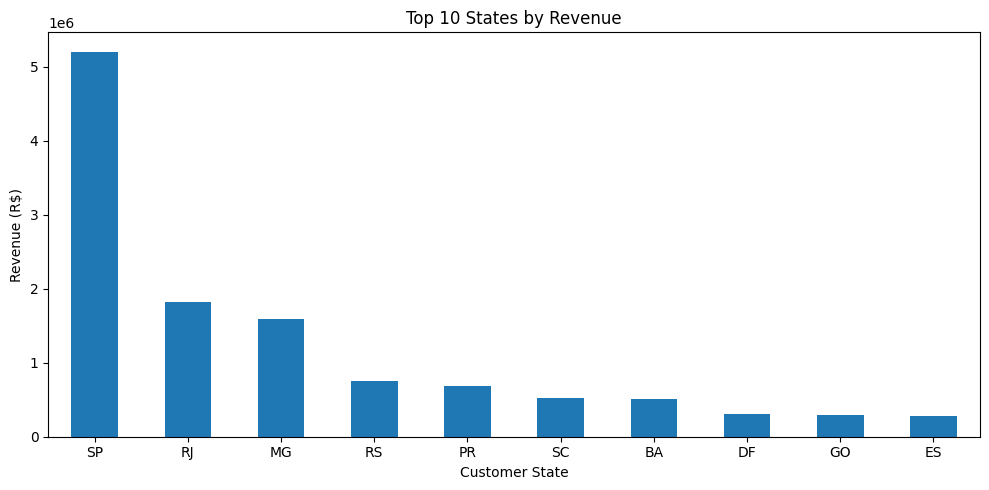

In [18]:
top_states = state_revenue.head(10)

top_states.plot(
    x='customer_state',
    y='revenue',
    kind='bar',
    figsize=(10, 5),
    legend=False
)

plt.title('Top 10 States by Revenue')
plt.xlabel('Customer State')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Business Insight 3: São Paulo generated by far the highest revenue at approximately R$5.20 million, followed by Rio de Janeiro at R$1.82 million and Minas Gerais at R$1.59 million. This shows that a large share of sales is concentrated in a few key states, particularly São Paulo, which appears to be the company’s most important geographic market.

10. Business Question 4: Do late deliveries lead to lower review scores?

In [19]:
delivery_reviews = (
    orders
    .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')
)

delivery_reviews['delivery_delay_days'] = (
    delivery_reviews['order_delivered_customer_date']
    - delivery_reviews['order_estimated_delivery_date']
).dt.days

delivery_reviews[['review_score', 'delivery_delay_days']].head()

,review_score,delivery_delay_days
0,4.0,-8.0
1,4.0,-6.0
2,5.0,-18.0
3,5.0,-13.0
4,5.0,-10.0


In [20]:
delivery_reviews['delivery_status'] = delivery_reviews['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0 else 'On time / Early'
)

review_by_delivery = (
    delivery_reviews
    .groupby('delivery_status', as_index=False)['review_score']
    .mean()
)

review_by_delivery

,delivery_status,review_score
0,Late,2.271139
1,On time / Early,4.211789


In [21]:
delivery_reviews_clean = delivery_reviews.dropna(
    subset=['delivery_delay_days', 'review_score']
).copy()

delivery_reviews_clean['delivery_status'] = delivery_reviews_clean[
    'delivery_delay_days'
].apply(
    lambda x: 'Late' if x > 0 else 'On time / Early'
)

review_by_delivery = (
    delivery_reviews_clean
    .groupby('delivery_status', as_index=False)['review_score']
    .mean()
)

review_by_delivery

,delivery_status,review_score
0,Late,2.271139
1,On time / Early,4.289842


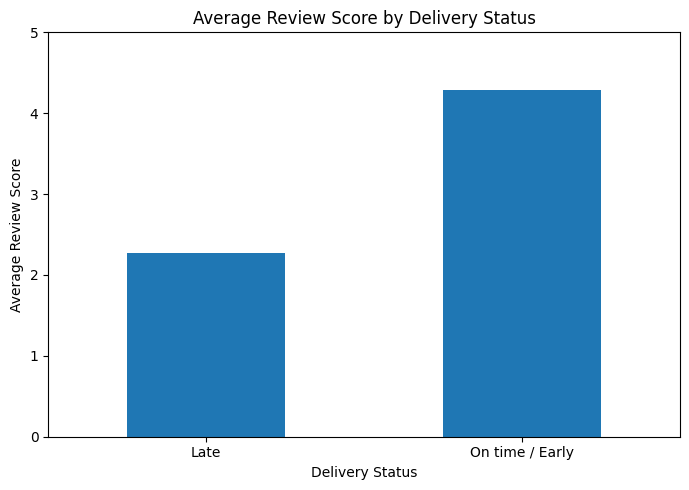

In [22]:
review_by_delivery.plot(
    x='delivery_status',
    y='review_score',
    kind='bar',
    figsize=(7, 5),
    legend=False
)

plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

Business Insight 4: Delivery timing has a strong relationship with customer satisfaction. Late deliveries received an average review score of approximately 2.27 out of 5, compared with about 4.29 out of 5 for orders delivered on time or early. This suggests that improving delivery reliability could have a significant positive effect on customer experience.

11. Business Question 5: How many customers made repeat purchases?

In [23]:
customer_orders = (
    customers
    .merge(orders[['customer_id', 'order_id']], on='customer_id', how='left')
    .groupby('customer_unique_id', as_index=False)['order_id']
    .nunique()
    .rename(columns={'order_id': 'order_count'})
)

customer_orders.head()

,customer_unique_id,order_count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [24]:
repeat_customers = customer_orders[
    customer_orders['order_count'] > 1
]

repeat_customer_count = repeat_customers['customer_unique_id'].nunique()
total_customer_count = customer_orders['customer_unique_id'].nunique()

repeat_rate = (repeat_customer_count / total_customer_count) * 100

print(f'Repeat customers: {repeat_customer_count:,}')
print(f'Total unique customers: {total_customer_count:,}')
print(f'Repeat customer rate: {repeat_rate:.2f}%')

Repeat customers: 2,997
Total unique customers: 96,096
Repeat customer rate: 3.12%


Business Insight 5: Only 3.12% of customers made repeat purchases, with 2,997 repeat customers out of 96,096 unique customers. This suggests that repeat purchasing was relatively low during the period covered by the dataset. Improving retention strategies, loyalty incentives, or post-purchase engagement could potentially encourage more customers to return.

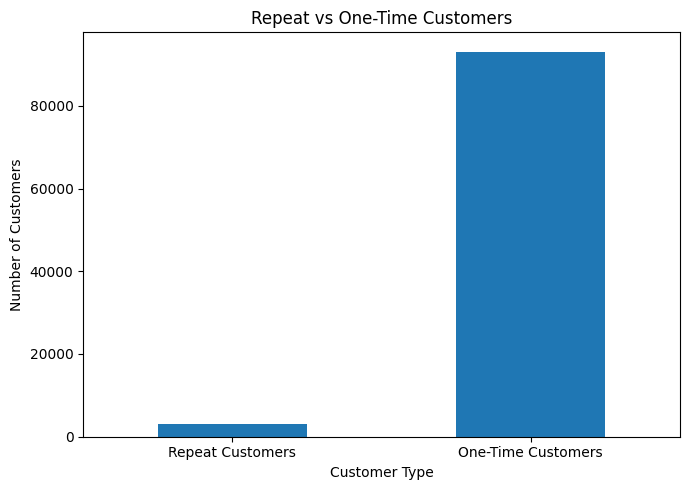

In [25]:
customer_type_counts = pd.DataFrame({
    'Customer Type': ['Repeat Customers', 'One-Time Customers'],
    'Count': [
        repeat_customer_count,
        total_customer_count - repeat_customer_count
    ]
})

customer_type_counts.plot(
    x='Customer Type',
    y='Count',
    kind='bar',
    figsize=(7, 5),
    legend=False
)

plt.title('Repeat vs One-Time Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

12. Business Question 6: Which payment methods are used most often?

In [26]:
payment_counts = (
    payments
    .groupby('payment_type', as_index=False)['order_id']
    .nunique()
    .rename(columns={'order_id': 'order_count'})
    .sort_values('order_count', ascending=False)
)

payment_counts

,payment_type,order_count
1,credit_card,76505
0,boleto,19784
4,voucher,3866
2,debit_card,1528
3,not_defined,3


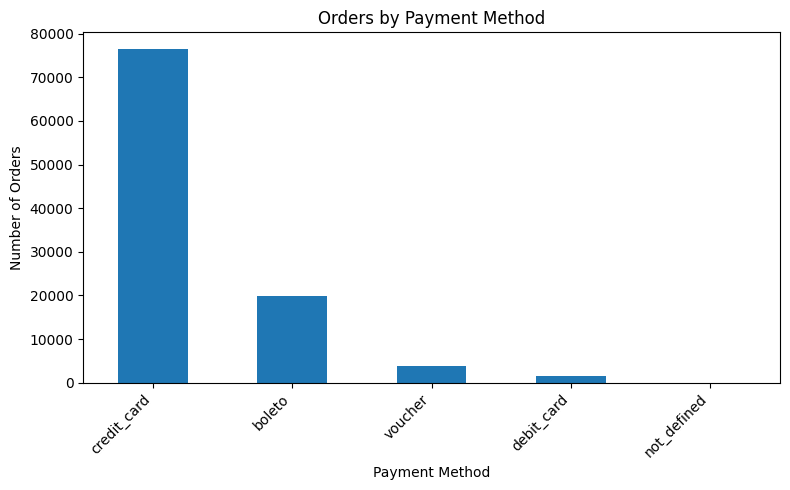

In [27]:
payment_counts.plot(
    x='payment_type',
    y='order_count',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Business Insight 6: Credit cards were by far the most commonly used payment method, appearing in 76,505 orders, followed by boleto with 19,784 orders. Voucher and debit-card usage was much lower. This indicates that credit-card payment was the dominant payment preference among customers in the dataset.

13. Business Question 7: Which sellers generate the most revenue?

In [28]:
sellers = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv')

sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [29]:
seller_revenue = (
    items
    .groupby('seller_id', as_index=False)['price']
    .sum()
    .rename(columns={'price': 'revenue'})
    .sort_values('revenue', ascending=False)
)

seller_revenue.head(10)

,seller_id,revenue
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63
1013,53243585a1d6dc2643021fd1853d8905,222776.05
881,4a3ca9315b744ce9f8e9374361493884,200472.92
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55
1824,955fee9216a65b617aa5c0531780ce60,135171.70


In [30]:
top_sellers = (
    seller_revenue
    .head(10)
    .merge(sellers, on='seller_id', how='left')
)

top_sellers[['seller_id', 'seller_city', 'seller_state', 'revenue']]

,seller_id,seller_city,seller_state,revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,229472.63
1,53243585a1d6dc2643021fd1853d8905,lauro de freitas,BA,222776.05
2,4a3ca9315b744ce9f8e9374361493884,ibitinga,SP,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,sumare,SP,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,itaquaquecetuba,SP,187923.89
5,7e93a43ef30c4f03f38b393420bc753a,barueri,SP,176431.87
6,da8622b14eb17ae2831f4ac5b9dab84a,piracicaba,SP,160236.57
7,7a67c85e85bb2ce8582c35f2203ad736,sao paulo,SP,141745.53
8,1025f0e2d44d7041d6cf58b6550e0bfa,sao paulo,SP,138968.55
9,955fee9216a65b617aa5c0531780ce60,sao paulo,SP,135171.70


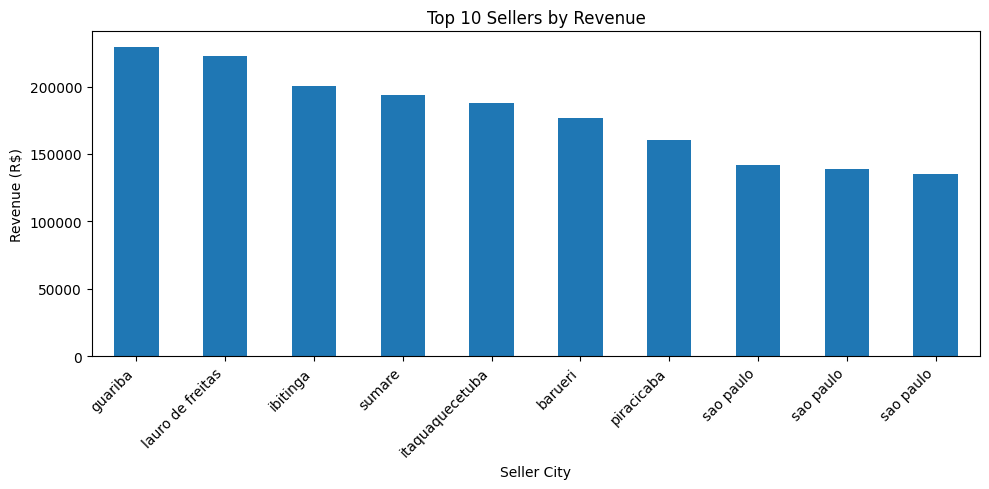

In [31]:
top_sellers.plot(
    x='seller_city',
    y='revenue',
    kind='bar',
    figsize=(10, 5),
    legend=False
)

plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Seller City')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Business Insight 7: The highest-performing individual seller generated approximately R$229,473 in item revenue, followed closely by the second-ranked seller at about R$222,776. Revenue was distributed across several high-performing sellers rather than being dominated by a single seller.

14. SQL Analysis

In [32]:
import sqlite3

conn = sqlite3.connect(':memory:')

orders.to_sql('orders', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
items.to_sql('order_items', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')
sellers.to_sql('sellers', conn, index=False, if_exists='replace')

print("SQL database created successfully.")

SQL database created successfully.


SQL Query 1: Preview the orders table

In [33]:
query = """
SELECT *
FROM orders
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,2017-07
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,None,None,2017-05-09 00:00:00,2017-04
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,2017-05
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,2017-01
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,2017-07


SQL Query 2: Count orders by status

In [34]:
query = """
SELECT
    order_status,
    COUNT(*) AS order_count
FROM orders
GROUP BY order_status
ORDER BY order_count DESC;
"""

pd.read_sql_query(query, conn)

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


SQL Query 3: Revenue by customer state using a JOIN

In [35]:
query = """
SELECT
    c.customer_state,
    ROUND(SUM(i.price), 2) AS revenue
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
JOIN order_items i
    ON o.order_id = i.order_id
GROUP BY c.customer_state
ORDER BY revenue DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,customer_state,revenue
0,SP,5202955.05
1,RJ,1824092.67
2,MG,1585308.03
3,RS,750304.02
4,PR,683083.76
5,SC,520553.34
6,BA,511349.99
7,DF,302603.94
8,GO,294591.95
9,ES,275037.31


SQL Query 4: Top product categories by revenue

In [36]:
translation.to_sql(
    'product_category_translation',
    conn,
    index=False,
    if_exists='replace'
)

print("Translation table added.")

Translation table added.


In [37]:
query = """
SELECT
    t.product_category_name_english AS product_category,
    ROUND(SUM(i.price), 2) AS revenue
FROM order_items i
JOIN products p
    ON i.product_id = p.product_id
JOIN product_category_translation t
    ON p.product_category_name = t.product_category_name
GROUP BY t.product_category_name_english
ORDER BY revenue DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,product_category,revenue
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46
